<a href="https://colab.research.google.com/github/Suleymanov23/ecommerce-A-B-testing-analysis/blob/main/A_B_testing_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A/B Testing Project: Prioritizing hypotheses and analysing test results

**Context:** Thinking myself as an analyst of a big online store,
 Together with the marketing department, I've compiled a list of hypotheses that may help boost revenue.
**The Project goals**:

1. **PART 1** - Priotizing hyphotezes using ICE and RICE formulas and compare teh results
2. **PART 2** - Analysing the results of A/b test and deciding on what to do (stop the test and declare a winning group, stop the test and conclude there is no difference, or continue testing.)

**Used datasets:**
- hypotheses_us.csv - 9 hypotheses with their Reach, Impact, Confidence, and Effort scores.
- orders_us.csv - Orders placed during the A/B test.
- visits_us.csv - Daily visits during the A/B test.

## 0. Libraries

- `pandas` - ddata manipulation,
- `numpy` - mathematical and statistical operations,
- `matplotlib` - visualation,
- `scipy.stats` - statistical testing (Mann-Whitney U)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
hypotheses = pd.read_csv('/content/drive/MyDrive/Projects/A-B test_3/hypotheses_us.csv', sep=';')
orders = pd.read_csv('/content/drive/MyDrive/Projects/A-B test_3/orders_us.csv')
visits = pd.read_csv('/content/drive/MyDrive/Projects/A-B test_3/visits_us.csv')

hypotheses.columns = ['hypothesis', 'reach', 'impact', 'confidence', 'effort']

print('hypotheses shape:', hypotheses.shape)
print('orders shape:', orders.shape)
print('visits shape:', visits.shape)

hypotheses shape: (9, 5)
orders shape: (1197, 5)
visits shape: (62, 3)


In [ ]:
for df in [hypotheses, orders, visits]:
  df.info()
  print('Missing values: \n', df.isna().sum())
  print('Duplicates:', df.duplicated().sum())
  print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   hypothesis  9 non-null      object
 1   reach       9 non-null      int64 
 2   impact      9 non-null      int64 
 3   confidence  9 non-null      int64 
 4   effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes
Missing values: 
 hypothesis    0
reach         0
impact        0
confidence    0
effort        0
dtype: int64
Duplicates: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64

In [ ]:
# In the orders dataset, every transaction_id must be unique
orders['transactionId'].duplicated().sum()

np.int64(0)

There are no missing values in any of them. Only, the date columns in orders and visits tables are 'object', which should be 'datetime'.

## PART 1. Priotizing hypotheses

There are 9 hypotheses and each evaluated on four metric (ranging from 1 to 10)
- **Reach** - how many users will be effected (1-10)
- **Impact** - how strongly it will effect users (1-10)
- **Confidence** - how confident we are about the impact (1-10)
- **Effort** - What it costs to test (1-10)

### ICE Formulası

$$ICE = \frac{Impact \times Confidence}{Effort}$$

ICE is dependent on 'impact', 'confidence', and 'effort', but not 'reach'. It means, while there is less users effected it can result high.

In [ ]:
hypotheses['ICE'] = (hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']

#For showing the hypotheses fully
pd.set_option('display.max_colwidth', None)

ice_sorted = hypotheses[['hypothesis', 'ICE']].sort_values(by='ICE', ascending=False).reset_index(drop=True)
ice_sorted.index += 1                                                                                            # the first one should be 1 not zeroth place
ice_sorted

,hypothesis,ICE
1,Launch a promotion that gives users discounts on their birthdays,16.200000
2,Add two new channels for attracting traffic. This will bring 30% more users,13.333333
3,Add a subscription form to all the main pages. This will help you compile a mailing list,11.200000
4,Show banners with current offers and sales on the main page. This will boost conversion,8.000000
5,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,7.000000
6,Launch your own delivery service. This will shorten delivery time,2.000000
7,Add a customer review page. This will increase the number of orders,1.333333
8,Change the category structure. This will increase conversion since users will find the products they want more quickly,1.125000
9,Change the background color on the main page. This will increase user engagement,1.000000


### RICE Formula

$$RICE = \frac{Reach \times Impact \times Confidence}{Effort}$$

Different from ICE, RICE is dependent on 'reach'. This is crucial for fairly comparing ideas that have a high impact on a small number of users and ideas that have a moderate impact but reach the entire user base.

In [ ]:
hypotheses['RICE'] = (hypotheses['reach'] * hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']

rice_sorted = hypotheses[['hypothesis', 'RICE']].sort_values(by='RICE', ascending=False).reset_index(drop=True)
rice_sorted.index += 1
rice_sorted

,hypothesis,RICE
1,Add a subscription form to all the main pages. This will help you compile a mailing list,112.0
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,56.0
3,Add two new channels for attracting traffic. This will bring 30% more users,40.0
4,Show banners with current offers and sales on the main page. This will boost conversion,40.0
5,Launch a promotion that gives users discounts on their birthdays,16.2
6,Change the category structure. This will increase conversion since users will find the products they want more quickly,9.0
7,Launch your own delivery service. This will shorten delivery time,4.0
8,Add a customer review page. This will increase the number of orders,4.0
9,Change the background color on the main page. This will increase user engagement,3.0


In [ ]:
hypotheses

,hypothesis,reach,impact,confidence,effort,ICE,RICE
0,Add two new channels for attracting traffic. This will bring 30% more users,3,10,8,6,13.333333,40.0
1,Launch your own delivery service. This will shorten delivery time,2,5,4,10,2.000000,4.0
2,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,8,3,7,3,7.000000,56.0
3,Change the category structure. This will increase conversion since users will find the products they want more quickly,8,3,3,8,1.125000,9.0
4,Change the background color on the main page. This will increase user engagement,3,1,1,1,1.000000,3.0
5,Add a customer review page. This will increase the number of orders,3,2,2,3,1.333333,4.0
6,Show banners with current offers and sales on the main page. This will boost conversion,5,3,8,3,8.000000,40.0
7,Add a subscription form to all the main pages. This will help you compile a mailing list,10,7,8,5,11.200000,112.0
8,Launch a promotion that gives users discounts on their birthdays,1,9,9,5,16.200000,16.2


### Comparing ICE and RICE

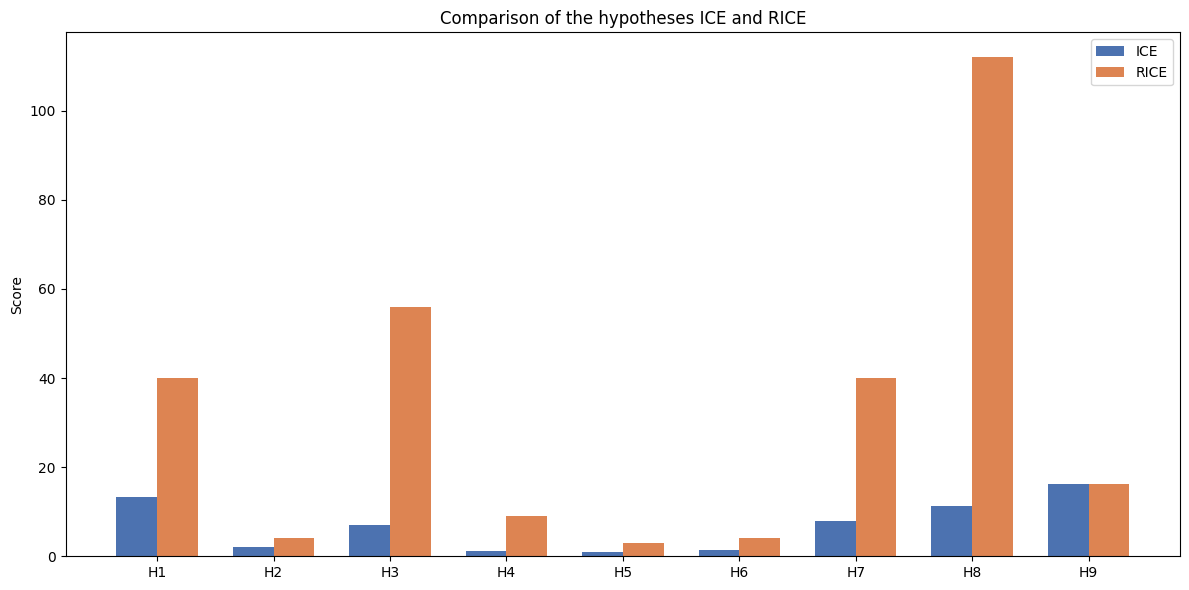

In [ ]:
# I will write H1,H2,...,H9 as hypotheses, because they are long in my graph
hypotheses['label'] = ['H' + str(i+1) for i in hypotheses.index]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(hypotheses))
width = 0.35

ax.bar(x- width/2, hypotheses['ICE'], width, label='ICE', color='#4C72B0')
ax.bar(x + width/2, hypotheses['RICE'], width, label='RICE', color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(hypotheses['label'])
ax.set_ylabel('Score')
ax.set_title('Comparison of the hypotheses ICE and RICE')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# I will show the ICE and RICE in the same table to clearly see the difference
hypotheses['ICE_rank'] = hypotheses['ICE'].rank(ascending=False).astype(int)
hypotheses['RICE_rank'] = hypotheses['RICE'].rank(ascending=False).astype(int)
hypotheses['rank_change'] = hypotheses['ICE_rank'] - hypotheses['RICE_rank']

rank_table = hypotheses[['label', 'hypothesis', 'reach', 'ICE_rank', 'RICE_rank', 'rank_change']].sort_values('RICE_rank').reset_index(drop=True)
rank_table.index += 1
rank_table

,label,hypothesis,reach,ICE_rank,RICE_rank,rank_change
1,H8,Add a subscription form to all the main pages. This will help you compile a mailing list,10,3,1,2
2,H3,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,8,5,2,3
3,H7,Show banners with current offers and sales on the main page. This will boost conversion,5,4,3,1
4,H1,Add two new channels for attracting traffic. This will bring 30% more users,3,2,3,-1
5,H9,Launch a promotion that gives users discounts on their birthdays,1,1,5,-4
6,H4,Change the category structure. This will increase conversion since users will find the products they want more quickly,8,8,6,2
7,H6,Add a customer review page. This will increase the number of orders,3,7,7,0
8,H2,Launch your own delivery service. This will shorten delivery time,2,6,7,-1
9,H5,Change the background color on the main page. This will increase user engagement,3,9,9,0


**Conclusion: ICE vs. RICE Comparison:**

In ICE top hypothesis is H9('Launch a promotion that gives users discounts on their birthdays'). It has very high 'impact' (9) and 'confidence' (9) scores and moderate 'effort' (5). Since ICE ignores 'reach', H9 scores high even though only affecting a small number of users (Reach = 1).

Under the RICE framework, H8 ("Add a subscription form to all the main pages") is the first pace. Its reach score is 10, meaning it affects almost all users. While it ranked 3rd in ICE, the massive reach pushes it to 1st place in RICE.

Conversely, H9 drops from 1st in ICE to 5th in RICE because its strong impact is limited to only 1/10 of the audience. A similar drop occurs for H1 (Reach = 3), which falls from 2nd to 3rd.

Meanwhile, H3 ("Add product recommendation blocks") rises from 5th in ICE to 2nd in RICE due to its reach (8).

> For business decisions knowing how many users an update will reach is just as important as knowing how strongly it will effect them. So, the testing order should be base on the RICE rankings

## PART 2. Analyses of A/B testing

### 2.1 Preprocessing

There might be mistakes in the original dataş For example, one user can not belong to both the control (A) and the test (B) group. I will check for full row duplicates and identify any users who were mistakenly assigned to both groups.

In [ ]:
# First let's convert date columns to 'datetime'
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

print('duplicated rows in orders:', orders.duplicated().sum())
print('duplicated rows in visits:', visits.duplicated().sum())
print('duplicated rows in A group:', orders[orders['group']== 'A'].duplicated().sum())
print('duplicated rows in B group:', orders[orders['group']== 'B'].duplicated().sum())

duplicated rows in orders: 0
duplicated rows in visits: 0
duplicated rows in A group: 0
duplicated rows in B group: 0


In [ ]:
A_users = set(orders.loc[orders['group'] == 'A', 'visitorId'])
B_users = set(orders.loc[orders['group'] == 'B', 'visitorId'])
users_in_both_groups = A_users & B_users

print('The number of the unique users in both groups:', len(users_in_both_groups))
print('The number of orders they ordered:', orders[orders['visitorId'].isin(users_in_both_groups)].shape[0])
print('This is', round(100 * orders['visitorId'].isin(users_in_both_groups).sum() / len(orders), 2), '% of all users')

The number of the unique users in both groups: 58
The number of orders they ordered: 181
This is 15.12 % of all users


Conclusion: Out of 1031 unique users, 58 were in both Group A and Group B. This makes 181 orders (~15% of total orders). To maintain statistical integrity, we should completly remove these users and their orders from the orders dataset. The visits dataset contains aggregated daily data without user IDs, so we can not touch anything there. Anyway the effect will not be that much big.

In [ ]:
clean_orders = orders[~orders['visitorId'].isin(users_in_both_groups)].reset_index(drop=True)

print('Orders count before cleaning:', len(orders))
print('Orders count after cleaning:', len(clean_orders))

orders = clean_orders

Orders count before cleaning: 1197
Orders count after cleaning: 1016


So, we will work on `orders` (cleaned) and `visits` (not possible to clean, at the same time not a big effect)

### 2.2 Building the base table for cumulative metrics

We use cumilative metrics because in daily graph we can not compare A and B, because it will be mixed (ziqzaq). So we rely on cumilative metrics, meaning the data is aggregated from the start of the test up to each specific day. To achieve this, we first need to build a structured "skeleton" dataframe. This table will calculate and store the accumulated number of orders, unique buyers, total revenue, and total visits for each group, day by day.

In [ ]:
visits_grouped = visits.sort_values(['date', 'group'])
visits_grouped['cum_visits'] = visits_grouped.groupby('group')['visits'].cumsum()

orders_grouped = orders.groupby(['date', 'group']).agg(orders=('transactionId', 'nunique'), revenue=('revenue', 'sum')).reset_index()

orders_grouped['cum_orders'] = orders_grouped.groupby('group')['orders'].cumsum()
orders_grouped['cum_revenue'] = orders_grouped.groupby('group')['revenue'].cumsum()


# First puchace date
first_purchase = orders.groupby(['visitorId', 'group'])['date'].min().reset_index()

# How many new buyers everday
new_buyers = first_purchase.groupby(['date', 'group']).agg(new_buyers=('visitorId', 'nunique')).reset_index()

new_buyers['cum_buyers'] = new_buyers.groupby('group')['new_buyers'].cumsum()

# Merging all together
cumulative_data =( orders_grouped[['date', 'group', 'cum_orders', 'cum_revenue']]
    .merge(new_buyers[['date', 'group', 'cum_buyers']], on=['date', 'group'])
    .merge(visits_grouped[['date', 'group', 'cum_visits']], on=['date', 'group']))

# I will rename them for not mixing with original
cumulative_data = cumulative_data.rename(columns={
    'cum_orders': 'orders',
    'cum_revenue': 'revenue',
    'cum_buyers': 'buyers',
    'cum_visits': 'visits'
})

cumulative_data.head()

,date,group,orders,revenue,buyers,visits
0,2019-08-01,A,23,2266.6,19,719
1,2019-08-01,B,17,967.2,17,713
2,2019-08-02,A,42,3734.9,36,1338
3,2019-08-02,B,40,3535.3,39,1294
4,2019-08-03,A,66,5550.1,60,1845


In [ ]:
# Seperating A and B
cum_a = cumulative_data[cumulative_data['group'] == 'A'].reset_index(drop=True)
cum_b = cumulative_data[cumulative_data['group'] == 'B'].reset_index(drop=True)

print('cum_a: \n', cum_a.head())
print()
print('cum_b: \n', cum_b.head())

cum_a: 
         date group  orders  revenue  buyers  visits
0 2019-08-01     A      23   2266.6      19     719
1 2019-08-02     A      42   3734.9      36    1338
2 2019-08-03     A      66   5550.1      60    1845
3 2019-08-04     A      77   6225.6      71    2562
4 2019-08-05     A      99   7623.6      92    3318

cum_b: 
         date group  orders  revenue  buyers  visits
0 2019-08-01     B      17    967.2      17     713
1 2019-08-02     B      40   3535.3      39    1294
2 2019-08-03     B      54   4606.9      53    1803
3 2019-08-04     B      68   6138.5      66    2573
4 2019-08-05     B      89   7587.8      87    3280


### 2.3 Cumulative revenue by group

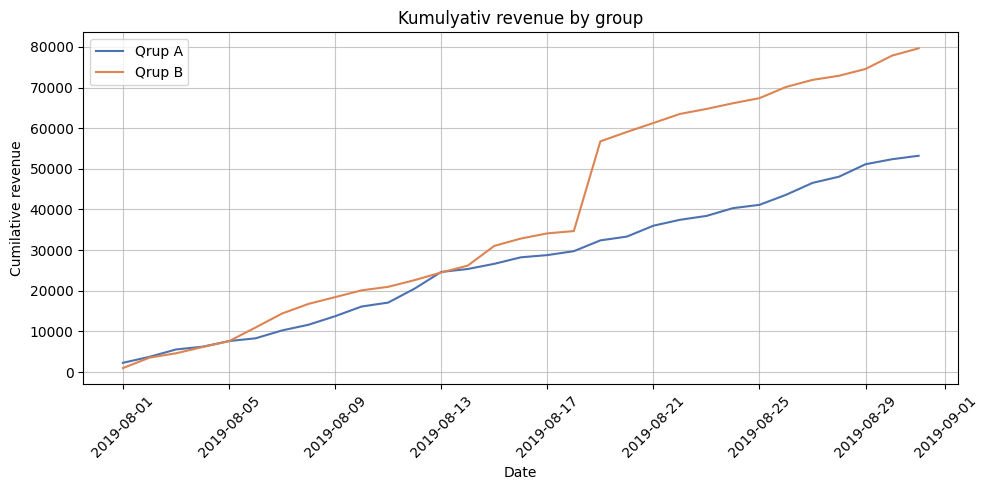

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(cum_a['date'], cum_a['revenue'], label='Qrup A', color='#4C72B0')
plt.plot(cum_b['date'], cum_b['revenue'], label='Qrup B', color='#DD8452')
plt.title('Kumulyativ revenue by group')
plt.xlabel('Date')
plt.ylabel('Cumilative revenue')
plt.legend()
plt.grid(True, alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

During the first half of the test (until around August 13), the cumulative revenue for groups A and B grows almost the same. However, at a certain point, B suddenly goes up (It may be because of expensive order). We will verify this hypothesis in next steps during the order price percentile analysis.

Although Group B seems above Group A after the spike, saying that B is leader,I would not say definitive conclusion without testing statistical significance.

### 2.4 Cumulative average order size by group

We should see both revenue and average order size because revenue always goes up, there can not be negative. But averige order size show dinamic.

Formula: avg_order_size = cumilative evenue / cumilative order count

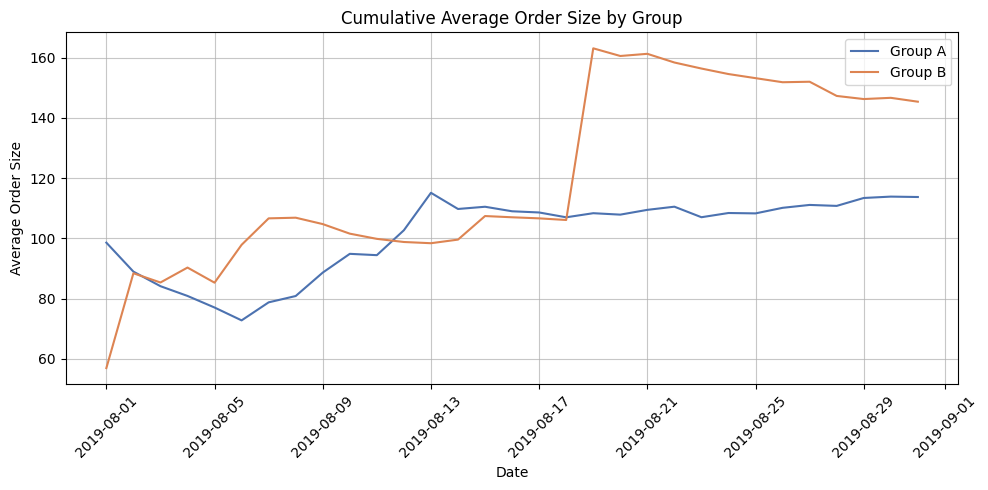

In [ ]:
cum_a['avg_order_size'] = cum_a['revenue'] / cum_a['orders']
cum_b['avg_order_size'] = cum_b['revenue'] / cum_b['orders']

plt.figure(figsize=(10, 5))
plt.plot(cum_a['date'], cum_a['avg_order_size'], label='Group A', color='#4C72B0')
plt.plot(cum_b['date'], cum_b['avg_order_size'], label='Group B', color='#DD8452')

plt.title('Cumulative Average Order Size by Group')
plt.xlabel('Date')
plt.ylabel('Average Order Size')
plt.legend()
plt.grid(True, alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Group A's average order size seems stable throughout the test. In contrast, Group B experiences a sharp spike on the exact same date as the revenue surge we saw in the previous graph. After this peak, Group B's average goes down.

This pattern is mostly because of one or a few very expensive orders which temporarily increases the cumilative average. After that expensive order, people order normal priced ones and the impact of these outliers decrease.
We visually saw that we must conduct statistical testing on filtered data (with anomalies revmoved) before making final decison.

### 2.5 Relative difference in cumulative average order size (Group B vs Group A)

Why we need this graph because human eye cannot see relative difference. For example, A group goes up from 100 to 110, but B goes up from 120 to 132. I would say they grow with the same speed, but relative difference is constant

Formula:
  Realtive difference = Group B / Group A - 1

/tmp/ipykernel_1738/3923354763.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


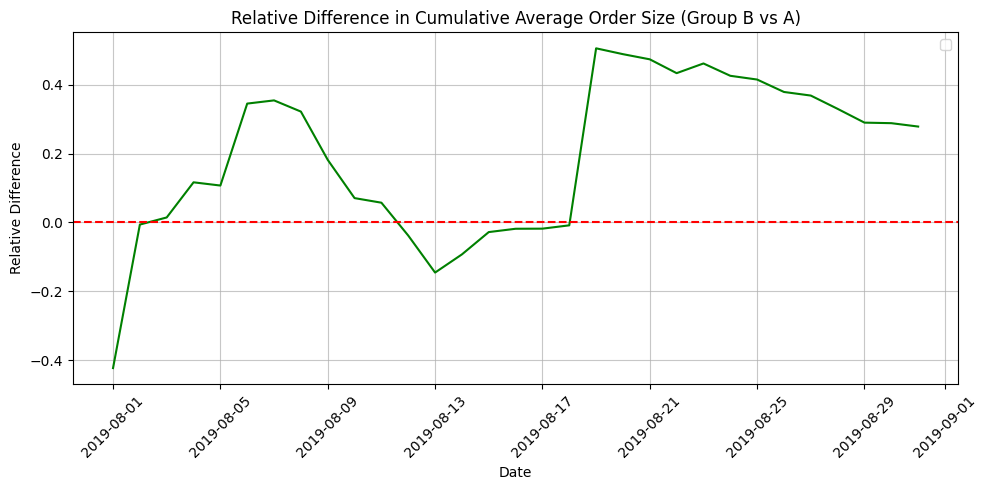

In [ ]:
# On merged table I calculate how much percent B is different from A (we did not work on 'cumulative_data' because there was not avg_order_size)
merged_avg =( cum_a[['date', 'avg_order_size']]
    .merge(cum_b[['date', 'avg_order_size']], on='date', suffixes=('_a', '_b')) )
merged_avg['relative_diff'] = merged_avg['avg_order_size_b'] / merged_avg['avg_order_size_a'] - 1

plt.figure(figsize=(10,5))
plt.plot(merged_avg['date'], merged_avg['relative_diff'], color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Relative Difference in Cumulative Average Order Size (Group B vs A)')
plt.xlabel('Date')
plt.ylabel('Relative Difference')
plt.legend()
plt.grid(True, alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*If the line is above the red line B grup wins, if the line is below the red line A group wins*

Conclusion:
The graph shows the relative difference drops to -40% on August 1st, climbs to about +35% between August 5-8, dips back into the negative around August 13, and then abruptly spikes to ~+50% on August 19 (remember the revenue spike observed earlier), remaining high thereafter.

If the difference were smooth and consistently positive, it would indicate a genuine advantage for Group B. However, such a "jumpy" and highly volatile trajectory strongly points to the presence of outliers (anomalous orders). Therefore, we cannot fully trust the results based on uncleaned data, we must verify them using filtered data.

### 2.6 Cumulative conversion rate by group

We plot the cumulative conversion rate to see if the new changes actually encourage a higher percentage of visitors to make a purchase. Unlike revenue the conversion rate treats every buyer equally, meaning this graph will not be distorted by one big purchase.

Formula:
  Conversion = Cumulative Orders / Cumulative Visits

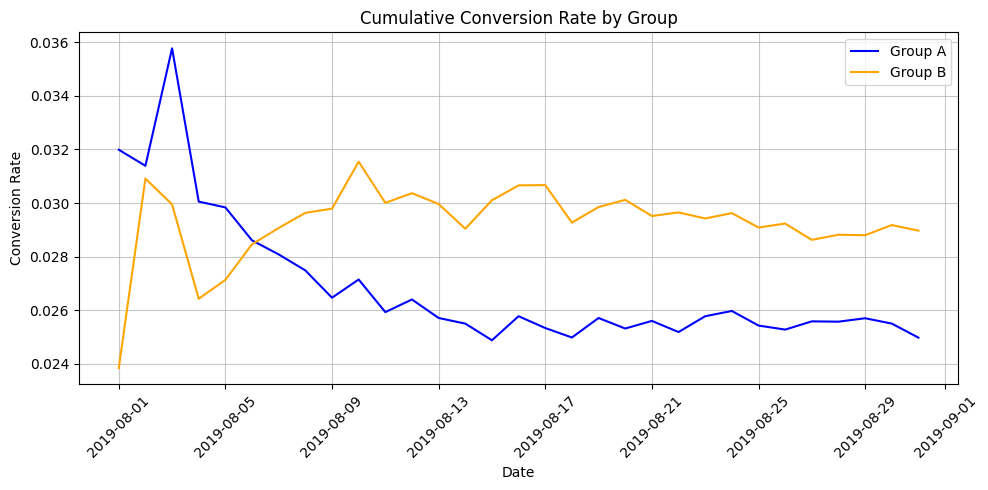

In [ ]:
cumulative_data['conversion'] = cumulative_data['orders'] / cumulative_data['visits']

cum_a_conv = cumulative_data[cumulative_data['group'] == 'A']
cum_b_conv = cumulative_data[cumulative_data['group'] == 'B']

plt.figure(figsize=(10, 5))
plt.plot(cum_a_conv['date'], cum_a_conv['conversion'], label='Group A', color='blue')
plt.plot(cum_b_conv['date'], cum_b_conv['conversion'], label='Group B', color='orange')

plt.title('Cumulative Conversion Rate by Group')
plt.xlabel('Date')
plt.ylabel('Conversion Rate')
plt.legend()
plt.grid(True, alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In the first few days, the conversion rates increases significantly, which is normal because a small initial sample size. Afterward, both groups stabilize. For the most part of the test, Group B's conversion rate goes consistently above Group A's.

Unlike the revenue graphs (which were skewed because of outliers), the conversion rate is not dependent on a single expensive order. This consistent gap can be considered as a reliable sign that Group B might have a genuine advantage in converting visitors into buyers. We will confirm this with statistical testing in the upcoming steps.

### 2.7 Distribution of orders per user

To see potential problematic values, I need to understand puchasing behaviour. Users who have an unusual high number of orders can artificially inmact our conversion rates and skew final test results. I will use scatter plot and histogram to visualize.

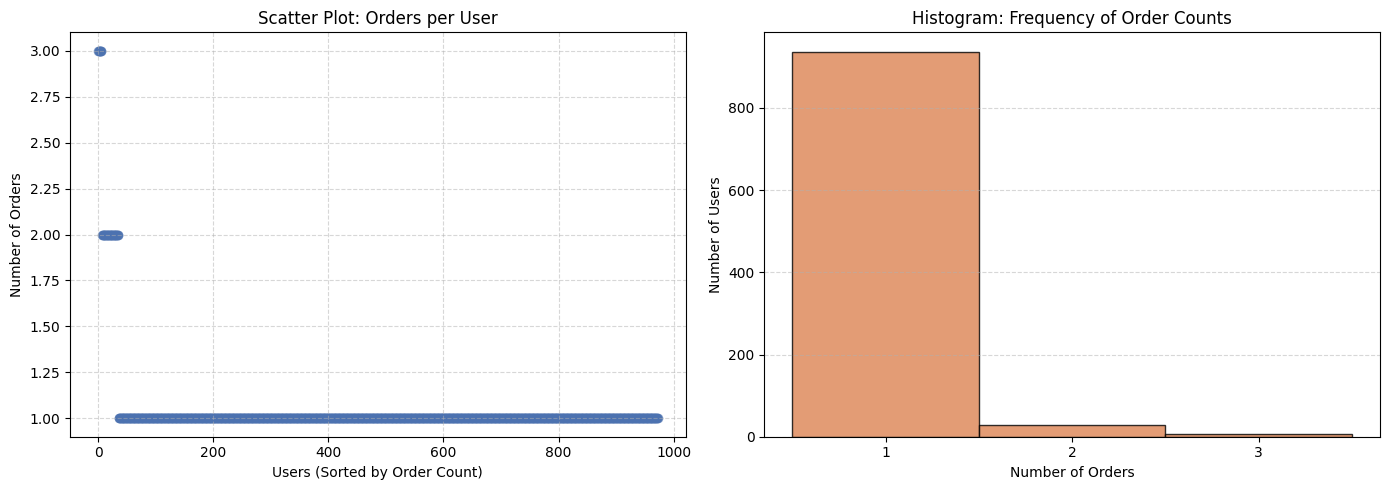

count    973.000000
mean       1.044193
std        0.238090
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: orders, dtype: float64


In [ ]:
# How many orders each users have given
orders_by_users = orders.groupby('visitorId', as_index=False).agg(orders=('transactionId', 'nunique'))
orders_by_users = orders_by_users.sort_values('orders', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Scatter Plot
axes[0].scatter(range(len(orders_by_users)), orders_by_users['orders'], alpha=0.6, color='#4C72B0')
axes[0].set_title('Scatter Plot: Orders per User')
axes[0].set_xlabel('Users (Sorted by Order Count)')
axes[0].set_ylabel('Number of Orders')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Histogram
axes[1].hist(orders_by_users['orders'], bins=range(1, orders_by_users['orders'].max() + 2),
             color='#DD8452', edgecolor='black', alpha=0.8, align='left')
axes[1].set_title('Histogram: Frequency of Order Counts')
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('Number of Users')
axes[1].set_xticks(range(1, orders_by_users['orders'].max() + 1))
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(orders_by_users['orders'].describe())

The visualizations clearly show that majority of users placed 1 order. A small part placed 2 orders. Users who placed more than 2 orders are rare and they are anomalies. These outliers have the potential to distort our average metrics. In the next step, we will calculate the exact percentiles to establish a mathematical threshold for filtering them

### 2.8 Calculating 95th and 99th percentilles for orders per user

Visualizing the data in a scatter plot was helpful, but filtering out anomalies should be based on a mathematical boundary.

In [ ]:
p95_orders =  np.percentile(orders_by_users['orders'], 95)
p99_orders = np.percentile(orders_by_users['orders'], 99)
print(f'95-ci percentil: {p95_orders}')
print(f'99-cu percentil: {p99_orders}')

95-ci percentil: 1.0
99-cu percentil: 2.0


The 95th percentile says that 95% of users have 1 order or les. The 99th percentile is 2 orders. So, I consider users who have more than 2 orders as anomalies. Since the majority (over than 95%) of users have only one order, having more than 2 is rare. These users will be filtered out during the final stage of our analysis.

### 2.9 Scatter plot of rrder prices

In our cumulative revenue graph (2.3), we observed a massive, unnatural spike for Group B. By plotting the individual revenue of every single order, we aim to isolate the exact extreme purchases that ruined our initial metrics.

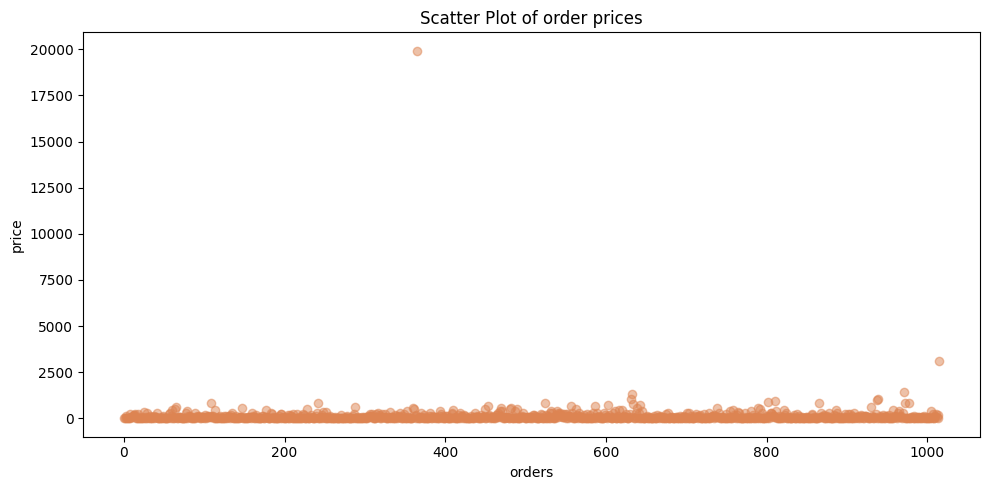

count     1016.000000
mean       130.770866
std        648.079810
min          5.000000
25%         20.775000
50%         50.100000
75%        126.950000
max      19920.400000
Name: revenue, dtype: float64


In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(range(len(orders)), orders['revenue'], alpha=0.5, color='#DD8452')
plt.title('Scatter Plot of order prices')
plt.xlabel('orders')
plt.ylabel('price')
plt.tight_layout()
plt.show()

print(orders['revenue'].describe())

There is at least one extreme outlier whose price is extremely higher than others. This single order is the exact reason behind the sharp revenue spike seen in Group B. Because this outlier stretches the y-axis, it compresses all normal orders into a thin line at the bottom.

### 2.10 95th and 99th percentiles for order prices

To be sure about anomalues in order prices (like the one that caused spike in group B), I use percenties

In [ ]:
p95_revenue = np.percentile(orders['revenue'], 95)
p99_revenue = np.percentile(orders['revenue'], 99)

print(f'95th percentil: {p95_revenue}')
print(f'99th percentil: {p99_revenue}')

95th percentil: 414.275
99th percentil: 830.3


The 95th percentile is 414.28 dollar, and the 99th percentile is 830.3 dollar. Orders costing more than the 99th percentile (the most expensive 1% of orders) are classified as anomalies. They sharply deviate from the typical purchasing behavior and disproportionately distort our average metrics. During the filtered analysis phase, we will exclude any orders above this.

### 2.11 Statistical significance of conversion rate

We will use the Mann-Whitney U test to check if the difference in conversion rates is statistically significant. We use this non-parametric test because the data (orders per user) is skewed and does not follow a normal distribution (most visitors place 0 or 1 order).

- H0 (Null Hypothesis): There is no statistically significant difference in conversion rates between Group A and Group B.
- H1 (Alternative Hypothesis): There is a statistically significant difference in conversion rates between the groups.Significance

Level ($a$(alpha)): 0.05

In [ ]:
alpha = 0.05

# Transaction count for each user by group
orders_by_users_a = orders[orders['group'] == 'A'].groupby('visitorId', as_index=False).agg(orders=('transactionId', 'nunique'))
orders_by_users_b = orders[orders['group'] == 'B'].groupby('visitorId', as_index=False).agg(orders=('transactionId', 'nunique'))

# For the ones that have visited but haven't ordered anything should be 0
visits_a_total = visits[visits['group'] == 'A']['visits'].sum()
visits_b_total = visits[visits['group'] == 'B']['visits'].sum()

sample_a = pd.concat([orders_by_users_a['orders'], pd.Series(0, index=np.arange(visits_a_total - len(orders_by_users_a)), name='orders')], axis=0)

sample_b = pd.concat([orders_by_users_b['orders'],pd.Series(0, index=np.arange(visits_b_total - len(orders_by_users_b)), name='orders')], axis=0)

# Man-Whitney U test
p_value = stats.mannwhitneyu(sample_a, sample_b, alternative='two-sided').pvalue
relative_gain = sample_b.mean() / sample_a.mean() - 1

print(f'p-value: {p_value}')
print(f'Relative gain of group B (B / A - 1): {relative_gain}')

if p_value < alpha:
    print('Result: Statistically Significant (Reject H0)')
else:
    print('Result: Not Statistically Significant (Fail to reject H0)')

p-value: 0.011018084110014696
Relative gain of group B (B / A - 1): 0.1597977924896936
Result: Statistically Significant (Reject H0)


The p-value (0.0110) is less than our alpha(0.05). Therefore, we reject the null hypothesis. There is a statistically significant difference in conversion between the groups. The relative gain is positive (~16%), meaning Group B's conversion rate is mathematically proven to be higher than Group A's based on the raw data. This confirms our earlier visual observations from the cumulative conversion graph.

### 2.12 Statistical significance of average oder size

I want to see if the new changes encouraged users to spend more money per order. We will again use the Mann-Whitney U test

In [ ]:
revenue_a = orders[orders['group'] == 'A']['revenue']
revenue_b = orders[orders['group'] == 'B']['revenue']

p_value_revenue = stats.mannwhitneyu(revenue_a, revenue_b, alternative='two-sided').pvalue
relative_gain_revenue = revenue_b.mean() / revenue_a.mean() - 1

print(f'p-value: {p_value_revenue}')
print(f'Relative differnce (B / A - 1): {relative_gain_revenue}')

if p_value_revenue < alpha:
  print('Statistically significant')
else:
  print('Statistically not significant')

p-value: 0.8622329690015668
Relative differnce (B / A - 1): 0.27834487693078414
Statistically not significant


The p-value (0.8622) is greater than 0.05 significance level. Therefore, we cannot reject the null hypothesis. There is no statistically significant difference in the average order size. Although the relative difference shows a 27.83% advantage for Group B, this is 'chance'. It does not reflect a true shift in user behavior but is entirely caused by the outliers we saw before.

### 2.13 Statistical Significance of conversion rate (Filtered data)

Now we have identified the anomalies (users with >2 orders or orders >$830.3), we must remove them from our dataset. Re-running the statistical test on this clean data will show us the true, unskewed effect of our changes on the conversion rate.

In [ ]:
# First: ones who ordered more than 2
users_with_many_orders = pd.concat([orders_by_users_a[orders_by_users_a['orders'] > p99_orders]['visitorId'],orders_by_users_b[orders_by_users_b['orders'] > p99_orders]['visitorId']], axis=0)

# Second: revenues more than 830.3 dollar
users_with_expensive_orders = orders[orders['revenue'] > p99_revenue]['visitorId']

# concatting both and keeping only unical IDs
anormal_users = pd.concat([users_with_many_orders, users_with_expensive_orders], axis=0).drop_duplicates()

print(f'Total number of anormal users: {len(anormal_users)}')


sample_a_filtered = pd.concat([orders_by_users_a[~orders_by_users_a['visitorId'].isin(anormal_users)]['orders'],pd.Series(0, index=np.arange(visits_a_total - len(orders_by_users_a)), name='orders')], axis=0)

sample_b_filtered = pd.concat([orders_by_users_b[~orders_by_users_b['visitorId'].isin(anormal_users)]['orders'],pd.Series(0, index=np.arange(visits_b_total - len(orders_by_users_b)), name='orders')], axis=0)

# Mann-Whitney U test
p_value_conv_filtered = stats.mannwhitneyu(sample_a_filtered, sample_b_filtered, alternative='two-sided').pvalue
relative_gain_conv_filtered = sample_b_filtered.mean() / sample_a_filtered.mean() - 1

print(f'p-value: {p_value_conv_filtered:.4f}')
print(f'Relative gain of Group B (Filtered Conversion): {relative_gain_conv_filtered:.2%}')

if p_value_conv_filtered < alpha:
    print('Result: Statistically Significant (Reject H0)')
else:
    print('Result: Not Statistically Significant (Fail to reject H0)')

Total number of anormal users: 16
p-value: 0.0070
Relative gain of Group B (Filtered Conversion): 18.92%
Result: Statistically Significant (Reject H0)


This timme also, the p-value (0.007) is below 0.05. Furthermore, the relative gain actually strengthens slightly to 18.92%. This is a strong signalç it proves that Group B's superiority in converting visitors into buyers is not depent on any outliers or extreeme purchases

### 2.14 Statistical significance of average order size (Filtered data)

We need to know if our previous conclusion (that there is no real difference in order size) is still true.

In [ ]:
revenue_a_filtered = orders[(orders['group'] == 'A') & (~orders['visitorId'].isin(anormal_users))]['revenue']
revenue_b_filtered = orders[(orders['group'] == 'B') & (~orders['visitorId'].isin(anormal_users))]['revenue']

p_value_revenue_filtered = stats.mannwhitneyu(revenue_a_filtered, revenue_b_filtered, alternative='two-sided').pvalue
relative_gain_revenue_filtered = revenue_b_filtered.mean() / revenue_a_filtered.mean() - 1

print(f'p-value: {p_value_revenue_filtered}')
print(f'relative diference (B / A - 1): {relative_gain_revenue_filtered}')

if p_value_revenue_filtered < alpha:
  print('Statisically significant')
else:
  print('Statistically not significant')

p-value: 0.8220253140355853
relative diference (B / A - 1): -0.03189908748968884
Statistically not significant


After removing the anormal orders, the p-value (0.822) is above 0.05. Interestingly, the relative difference drops sharply from 27.83% to -3.19%. This proves that the initial visual "advantage" of Group B in average order size was merely a statistical artifact caused by 1-2 extreme purchases. In reality, there is no systemic difference in how much users spend per order between the two groups.

## 2.15 Executive Summary and Final Decision

| Metric | raw data | filtered data |
|---|---|---|
| conversion rate | Statistcal significant, (B leads) | Statistikal singicant, B leads|
| Average order size | Not statistically signigicant | Not statistically significant |

Key Justifications:
- The conversion rate indicator is statistically significant and stable in favor of Group B across both raw and filtered data. This is a strong, real signal that is completely independent of anomalies.
- There is no statistically significant difference in the average order size at any stage. The initial spike in raw data was an artifact of a few extreme outlier orders.
- Although Group B's cumulative revenue graph was leading, this increase in revenue is driven entirely from the higher volume of orders (better conversion), not by an increase in the size of the ordes.

Final Decision: **Stop the test and declare Group B the leader.**

Group B's superiority in conversion has been rigorously proven and is resistant to outliers. Continuing the test would not yield additional statistical power regarding the average order size; it would merely be a waste of time and business resources. Implementing the changes from Group B will confidently drive more purchases and, consequently, higher overall revenue.